# 03 - Expression & Spatial Metadata, Dissected

## Learning objectives
1. Inspect `adata.X`, `.obs`, `.var`, `.obsm['spatial']`, `.uns['spatial']`.
2. Read off the number of spots and genes and peek at metadata.
3. Understand the spatial-coordinate structure and the image scale factors.
4. Make image-to-expression **registration** concrete with one multiply.

## Concept
We revisit the 'four data objects' from notebook 00, now on the real dataset. The goal is
that you can always answer: *where is the matrix? where are the coordinates? what units
are they in? how do they map onto the image?*


In [1]:
# --- Standard setup: make `utils` importable and seed RNGs ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'utils').exists():
    ROOT = ROOT.parent  # in case the notebook is opened from a subfolder
sys.path.insert(0, str(ROOT))

from utils import st_helpers as st
st.set_seeds()  # reproducibility (seed = 0)
print('Project root:', st.project_root())


Project root: /Users/justin/Documents/SpatialTranscriptomics-Tutorial


In [2]:
adata = st.load_adata('adata_raw.h5ad')
adata


AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### Spots and genes (matrix shape)

In [3]:
import numpy as np

n_spots, n_genes = adata.shape
print(f'Number of spots (obs): {n_spots:,}')
print(f'Number of genes (var): {n_genes:,}')
print('Type of .X         :', type(adata.X))
print('.X dtype           :', adata.X.dtype)


Number of spots (obs): 2,688
Number of genes (var): 18,078
Type of .X         : <class 'scipy.sparse._csr.csr_matrix'>
.X dtype           : float32


`.X` is typically a **sparse** matrix (most entries are 0 - a given spot expresses only a
fraction of all genes). This is like a mostly-empty volume; storing only non-zeros saves
huge memory.

In [4]:
# Look at a tiny dense corner of the count matrix.
import scipy.sparse as sp

X = adata.X
corner = X[:5, :8].toarray() if sp.issparse(X) else np.asarray(X[:5, :8])
print('First 5 spots x 8 genes (UMI counts):')
print(corner)

density = (X.nnz / (n_spots * n_genes)) if sp.issparse(X) else np.mean(X != 0)
print(f'\nMatrix density (fraction non-zero): {density:.3f}')


First 5 spots x 8 genes (UMI counts):
[[0.         0.         0.87893134 0.87893134 1.3393729  0.
  1.8921022  0.        ]
 [0.         0.         1.0922161  1.0922161  1.0922161  0.
  1.6017576  0.        ]
 [0.         0.         0.         0.         0.9803591  0.
  0.6057939  0.        ]
 [0.         0.         0.         0.         0.         0.
  2.4223483  0.        ]
 [0.         0.         0.99697125 0.         0.6179012  0.
  0.         0.        ]]

Matrix density (fraction non-zero): 0.317


**Expected output:** small integer UMI counts (many zeros) and a density well below 0.2 -
i.e. the matrix is sparse.

### `.obs` - per-spot metadata (rows of the matrix)

In [5]:
print('obs columns:', list(adata.obs.columns))
adata.obs.head()


obs columns: ['in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster']


,in_tissue,array_row,array_col,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,leiden,cluster
AAACAAGTATCTCCCA-1,1,50,102,4928,8.502891,19340.0,9.869983,38.428128,43.133402,49.214064,60.449845,3857.0,8.257904,19.943123,19340.0,2,Cortex_2
AAACAATCTACTAGCA-1,1,3,43,3448,8.145840,13750.0,9.528867,50.516364,55.141818,60.952727,70.574545,3267.0,8.091933,23.760000,13750.0,11,Cortex_5
AAACACCAATAACTGC-1,1,59,19,6022,8.703341,32710.0,10.395467,40.483033,47.071232,54.564353,65.087129,4910.0,8.499233,15.010699,32710.0,7,Thalamus_2
AAACAGAGCGACTCCT-1,1,14,94,4311,8.369157,15909.0,9.674704,40.957948,45.810547,52.077440,62.976931,3270.0,8.092851,20.554403,15909.0,11,Cortex_5
AAACCGGGTAGGTACC-1,1,42,28,5787,8.663542,31856.0,10.369013,40.287544,45.887745,52.982170,64.248493,6693.0,8.808967,21.010170,31856.0,7,Thalamus_2


Each row is one spot. Columns may include in-tissue flags and array row/col indices.
(Quality-control columns like `total_counts` get added in notebook 04.)

### `.var` - per-gene metadata (columns of the matrix)

In [6]:
print('var columns:', list(adata.var.columns))
print('first 10 gene names:', list(adata.var_names[:10]))
adata.var.head()


var columns: ['gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm']
first 10 gene names: ['Xkr4', 'Sox17', 'Mrpl15', 'Lypla1', 'Tcea1', 'Rgs20', 'Atp6v1h', 'Oprk1', 'Npbwr1', 'Rb1cc1']


,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,False,233,0.093032,0.088955,91.363973,251.0,5.529429,233,False,NaN,0.093378,0.098832,0.815019
Sox17,ENSMUSG00000025902,Gene Expression,mm10,False,298,0.128243,0.120662,88.954781,346.0,5.849325,298,False,NaN,0.128720,0.156108,0.931378
Mrpl15,ENSMUSG00000033845,Gene Expression,mm10,False,1775,1.370645,0.863162,34.210526,3698.0,8.215817,1775,False,NaN,1.375744,2.163193,0.850736
Lypla1,ENSMUSG00000025903,Gene Expression,mm10,False,1294,0.741290,0.554626,52.038547,2000.0,7.601402,1293,False,NaN,0.743676,0.984143,0.873699
Tcea1,ENSMUSG00000033813,Gene Expression,mm10,False,1975,1.727947,1.003549,26.797628,4662.0,8.447414,1974,False,NaN,1.734003,3.030447,0.856292


Note the gene-name casing (mouse: `Snap25`; human would be `SNAP25`). This is why we
always filter marker lists through `st.genes_present()`.

### `.obsm['spatial']` - spot coordinates

In [7]:
coords = adata.obsm['spatial']
print('coords shape:', coords.shape, '(n_spots, 2) -> columns are [x_pixel, y_pixel]')
print('x range:', coords[:, 0].min(), '..', coords[:, 0].max())
print('y range:', coords[:, 1].min(), '..', coords[:, 1].max())
print('first 5 coords:\n', coords[:5])


coords shape: (2688, 2) (n_spots, 2) -> columns are [x_pixel, y_pixel]
x range: 1969 .. 8574
y range: 1252 .. 9991
first 5 coords:
 [[8230 7237]
 [4170 1611]
 [2519 8315]
 [7679 2927]
 [3138 6280]]


These are **full-resolution image pixels**. They are the link between a matrix row and a
location on the H&E photograph.

### `.uns['spatial']` - the image and scale factors

In [8]:
lib = st.get_library_id(adata)
sf = st.get_scalefactors(adata)
for k, v in sf.items():
    print(f'{k:>28}: {v}')

hires = st.get_image(adata, 'hires')
lowres = st.get_image(adata, 'lowres')
print('\nhires image array shape :', hires.shape)
print('lowres image array shape:', lowres.shape)


   fiducial_diameter_fullres: 144.48769000651953
       spot_diameter_fullres: 89.44476048022638
         tissue_hires_scalef: 0.17011142
        tissue_lowres_scalef: 0.051033426

hires image array shape : (2000, 1921, 3)
lowres image array shape: (600, 576, 3)


Key scale factors:
- `tissue_hires_scalef` / `tissue_lowres_scalef` - multiply a full-res pixel coordinate by
  this to land on the `hires` / `lowres` image.
- `spot_diameter_fullres` - the spot's diameter **in full-resolution pixels** (we use this
  in notebook 09 to size image patches).

### Registration in one multiply
Let's overlay the spots on the hires image to *prove* the coordinates and scale factor are
consistent. (Notebook 06 does the polished version; this is the bare-bones check.)

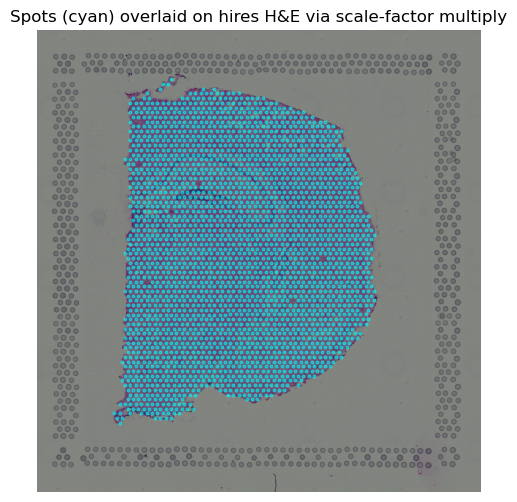

In [9]:
import matplotlib.pyplot as plt

scalef = sf['tissue_hires_scalef']
xy_hires = coords * scalef  # full-res pixels -> hires-image pixels

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(hires)
ax.scatter(xy_hires[:, 0], xy_hires[:, 1], s=4, c='cyan', alpha=0.5)
ax.set_title('Spots (cyan) overlaid on hires H&E via scale-factor multiply')
ax.axis('off')
plt.show()


### Registration check: misaligned vs aligned overlay
The most common registration bug is plotting **full-resolution** spot coordinates on the
**downscaled** `hires` image *without* multiplying by `tissue_hires_scalef`. The left panel
below shows that failure; the right panel shows the correct multiply.

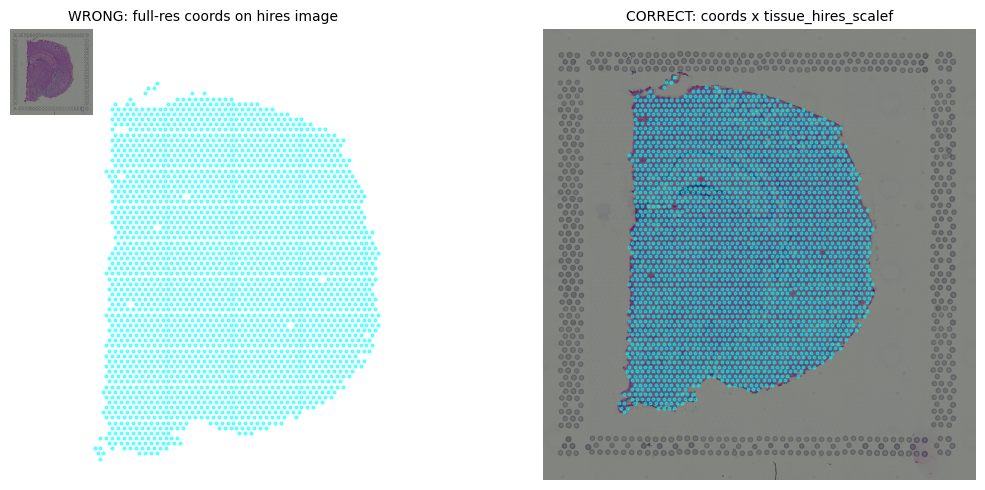

Misaligned dots sit in a corner or off-tissue; aligned dots tile the tissue.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, xy, title in [
    (axes[0], coords, 'WRONG: full-res coords on hires image'),
    (axes[1], xy_hires, 'CORRECT: coords x tissue_hires_scalef'),
]:
    ax.imshow(hires)
    ax.scatter(xy[:, 0], xy[:, 1], s=4, c='cyan', alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
st.save_fig(fig, '03_registration_misaligned_vs_aligned.png')
plt.show()
print('Misaligned dots sit in a corner or off-tissue; aligned dots tile the tissue.')


<details>
<summary><b>Your turn (exercise)</b></summary>

**Prompt:** A colleague overlays spots on the hires image and they land in the top-left
corner. What did they forget?

**Expected answer:** They used `adata.obsm['spatial']` directly without multiplying by
`adata.uns['spatial'][lib]['scalefactors']['tissue_hires_scalef']`. Full-res pixel
coordinates must be scaled down to match the hires image resolution.
</details>


**Expected output:** cyan dots tiling exactly over the tissue in the H&E image. If the
dots are shifted or shrunk into a corner, you forgot the scale-factor multiply (a classic
registration bug).

## The six distinctions, on real data
| Concept | This dataset |
|---|---|
| Tissue image pixels | `hires`/`lowres` RGB arrays in `uns['spatial']` |
| Visium spots | the ~2,700 rows of `adata` |
| Count matrix | `adata.X` (sparse UMI counts) |
| Spatial coordinates | `adata.obsm['spatial']` (full-res pixels) |
| Scale factors | `uns['spatial'][lib]['scalefactors']` |
| Registration | coordinate x `tissue_hires_scalef` |

## Common pitfalls
- Plotting raw coordinates on the (downscaled) hires image without the scale factor.
- Assuming `.X` is dense (it is usually sparse - convert small slices only).
- Confusing array indices (row/col on the spot grid) with pixel coordinates.

## Interpretation
You can now navigate any Visium AnnData blindfolded and explain how the matrix registers
to the image.

## What this means biologically
Each matrix row is a real, locatable patch of brain tissue. Keeping the row<->pixel link
intact is what lets us ask spatial biological questions later.

---
**Next:** `04_qc_and_preprocessing.ipynb` - clean and normalize the data.
